In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import tensor
import numpy as np
import math

In [2]:
torch.manual_seed(42)

In [3]:
model = nn.Linear(in_features=4, out_features=1)

In [4]:
x = torch.tensor([[1.0, 2.0, 3.0, 4.0]]) 

In [5]:
y = model(x)
print("PyTorch output:", y)

PyTorch output: tensor([[2.5885]], grad_fn=<AddmmBackward0>)


In [6]:
print("Weight:", model.weight)
print("Bias:", model.bias)

Weight: Parameter containing:
tensor([[ 0.3823,  0.4150, -0.1171,  0.4593]], requires_grad=True)
Bias: Parameter containing:
tensor([-0.1096], requires_grad=True)


In [7]:
y = tensor([[ 0.3823,  0.4150, -0.1171,  0.4593]]) * torch.tensor([[1.0, 2.0, 3.0, 4.0]]) 

In [8]:
y.sum()-0.1096

tensor(2.5886)

In [9]:
embedding_size = 64

attn = nn.MultiheadAttention(
    embed_dim=embedding_size,
    num_heads=1,
    batch_first=True
)

In [10]:
x = torch.rand(1, 5, embedding_size) 

In [11]:
output = attn(x, x, x)

In [12]:
len(output)

2

In [13]:
output[0].shape

torch.Size([1, 5, 64])

In [14]:
output[1].shape

torch.Size([1, 5, 5])

In [15]:
for name, param in attn.named_parameters():
    print(name, param)

in_proj_weight Parameter containing:
tensor([[ 0.1463,  0.0797, -0.0605,  ...,  0.1106,  0.0167, -0.0003],
        [-0.1480,  0.1343, -0.1012,  ..., -0.0493,  0.1001,  0.0220],
        [-0.0308,  0.0295, -0.1205,  ...,  0.0238, -0.1111,  0.0620],
        ...,
        [-0.0965,  0.0901,  0.0474,  ..., -0.0233,  0.0919,  0.0555],
        [ 0.0998, -0.1160, -0.1342,  ..., -0.1334, -0.1323,  0.0661],
        [ 0.0884, -0.1313,  0.1470,  ..., -0.1111,  0.1233, -0.1399]],
       requires_grad=True)
in_proj_bias Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [16]:
attn.in_proj_weight.shape

torch.Size([192, 64])

In [17]:
attn.out_proj.weight.shape

torch.Size([64, 64])

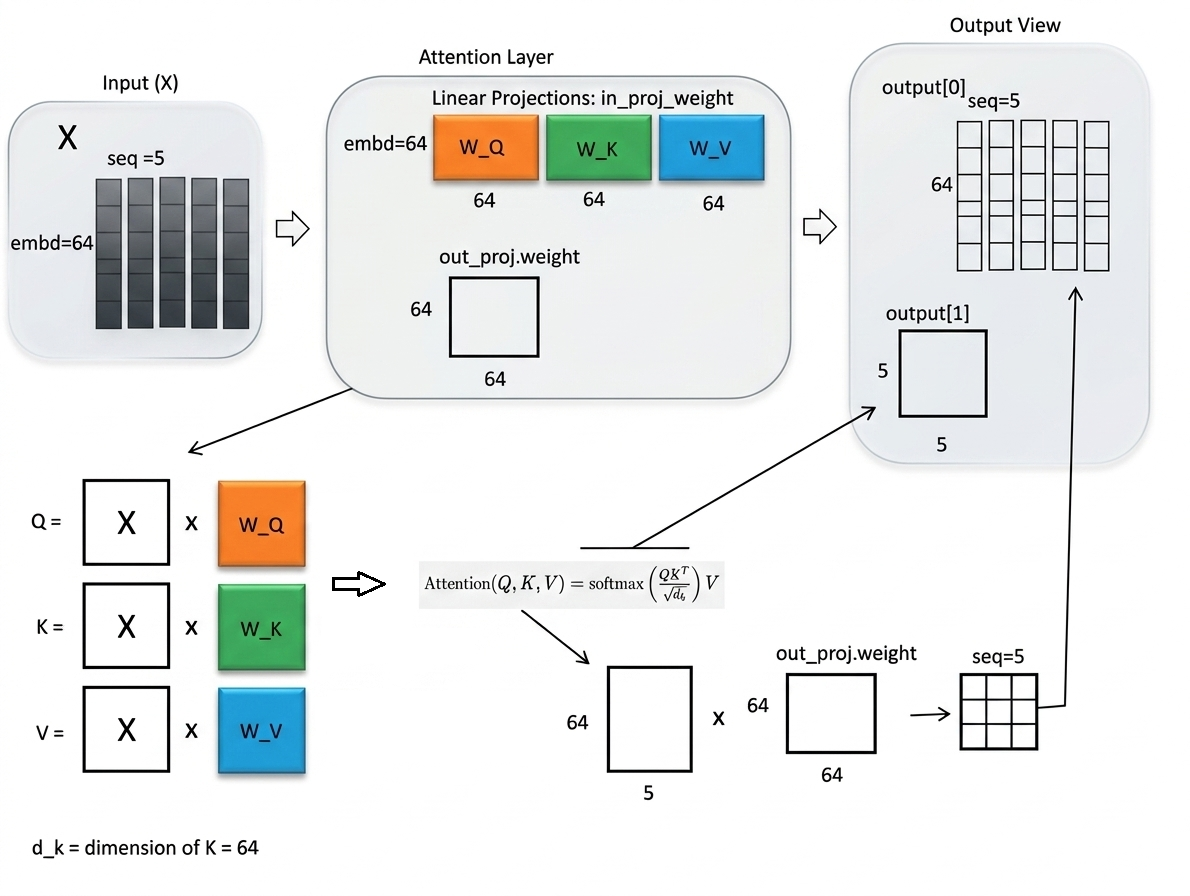

In [ ]:
from PIL import Image
Image.open("./manual.png")

In [19]:
W = attn.in_proj_weight 

W_Q, W_K, W_V = W.chunk(3, dim=0)

Q = x @ W_Q.T
K = x @ W_K.T
V = x @ W_V.T

d_k = K.size()[-1]

_temp = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(d_k)
attention = F.softmax(_temp, dim=-1)

In [29]:
_temp = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(d_k)

In [30]:
_temp

tensor([[[-0.0765, -0.0463,  0.0221, -0.0124,  0.2720],
         [-0.1516, -0.0276,  0.0428,  0.0898,  0.1688],
         [-0.0951,  0.0267, -0.0349, -0.0123,  0.1262],
         [-0.0472, -0.0619, -0.0342, -0.1111,  0.0441],
         [-0.1088, -0.0182,  0.0203,  0.0074,  0.2176]]],
       grad_fn=<DivBackward0>)

In [31]:
mask = torch.tril(torch.ones(5, 5))

In [32]:
mask

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])

In [33]:
_temp = _temp.masked_fill(mask == 0, float('-inf'))

In [34]:
_temp 

tensor([[[-0.0765,    -inf,    -inf,    -inf,    -inf],
         [-0.1516, -0.0276,    -inf,    -inf,    -inf],
         [-0.0951,  0.0267, -0.0349,    -inf,    -inf],
         [-0.0472, -0.0619, -0.0342, -0.1111,    -inf],
         [-0.1088, -0.0182,  0.0203,  0.0074,  0.2176]]],
       grad_fn=<MaskedFillBackward0>)

In [35]:
attention = F.softmax(_temp, dim=-1)

In [36]:
attention

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4690, 0.5310, 0.0000, 0.0000, 0.0000],
         [0.3133, 0.3539, 0.3328, 0.0000, 0.0000],
         [0.2540, 0.2503, 0.2574, 0.2383, 0.0000],
         [0.1742, 0.1907, 0.1982, 0.1956, 0.2414]]],
       grad_fn=<SoftmaxBackward0>)

In [20]:
attention.shape

torch.Size([1, 5, 5])

In [21]:
output[1].shape

torch.Size([1, 5, 5])

In [22]:
attention

tensor([[[0.1780, 0.1835, 0.1965, 0.1898, 0.2522],
         [0.1667, 0.1888, 0.2025, 0.2123, 0.2297],
         [0.1810, 0.2044, 0.1922, 0.1966, 0.2258],
         [0.1987, 0.1958, 0.2013, 0.1864, 0.2177],
         [0.1742, 0.1907, 0.1982, 0.1956, 0.2414]]],
       grad_fn=<SoftmaxBackward0>)

In [23]:
output[1]

tensor([[[0.1780, 0.1835, 0.1965, 0.1898, 0.2522],
         [0.1667, 0.1888, 0.2025, 0.2123, 0.2297],
         [0.1810, 0.2044, 0.1922, 0.1966, 0.2258],
         [0.1987, 0.1958, 0.2013, 0.1864, 0.2177],
         [0.1742, 0.1907, 0.1982, 0.1956, 0.2414]]], grad_fn=<MeanBackward1>)

In [24]:
torch.equal(attention, output[1])

True

In [25]:
values = torch.matmul(attention, V)
values = values @ attn.out_proj.weight.T

In [26]:
values.shape

torch.Size([1, 5, 64])

In [27]:
output[0].shape

torch.Size([1, 5, 64])

In [28]:
torch.equal(values, output[0])

True